In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data
df=pd.read_csv(r'D:\CompanyTask\Movies_project\movies.csv')

In [9]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [11]:
#Data Cleaning
#1. Check Missing Values
df.isnull().sum()

name           0
rating        77
genre          0
year           0
released       2
score          3
votes          3
director       0
writer         3
star           1
country        3
budget      2171
gross        189
company       17
runtime        4
dtype: int64

In [12]:
#Fill Missing Values
df['budget']=df['budget'].fillna(df['budget'].median())

In [13]:
#Fill votes
#Fill score
#Fill runtime
df['votes']=df['votes'].fillna(df['votes'].median())
df['score']=df['score'].fillna(df['score'].median())
df['runtime']=df['runtime'].fillna(df['runtime'].median())

In [17]:
#For Categorical Columns
#Fill with mode

df['rating'].unique()

array(['R', 'PG', 'G', 'Not Rated', 'NC-17', 'Approved', 'TV-PG', 'PG-13',
       'Unrated', 'X', 'TV-MA', 'TV-14'], dtype=object)

In [16]:
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [19]:
df['writer'] = df['writer'].fillna('Unknown')

In [22]:
df['country']=df['country'].fillna(df['country'].mode()[0])

In [23]:
df['company']=df['company'].fillna(df['company'].mode()[0])

In [ ]:
#Verify Missing Values Again
df.isnull().sum()

name          0
rating        0
genre         0
year          0
released      2
score         0
votes         0
director      0
writer        0
star          1
country       0
budget        0
gross       189
company       0
runtime       0
dtype: int64

In [26]:
#Drop only rows where gross is missing.
df=df.dropna(subset=['gross'])

In [27]:
#Fill remaining columns
df['star'] = df['star'].fillna('Unknown')
df['released'] = df['released'].fillna('Unknown')

In [28]:
#Confirm Everything is Clean
df.isnull().sum()

name        0
rating      0
genre       0
year        0
released    0
score       0
votes       0
director    0
writer      0
star        0
country     0
budget      0
gross       0
company     0
runtime     0
dtype: int64

In [29]:
df.dtypes

name         object
rating       object
genre        object
year          int64
released     object
score       float64
votes       float64
director     object
writer       object
star         object
country      object
budget      float64
gross       float64
company      object
runtime     float64
dtype: object

In [30]:
df.head()

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0


In [31]:
#Even though votes, budget, gross, runtime are float64 —
#they should logically be integers.
#This improves dataset quality.

df['votes'] = df['votes'].astype('int64')
df['budget'] = df['budget'].astype('int64')
df['gross'] = df['gross'].astype('int64')
df['runtime'] = df['runtime'].astype('int64')

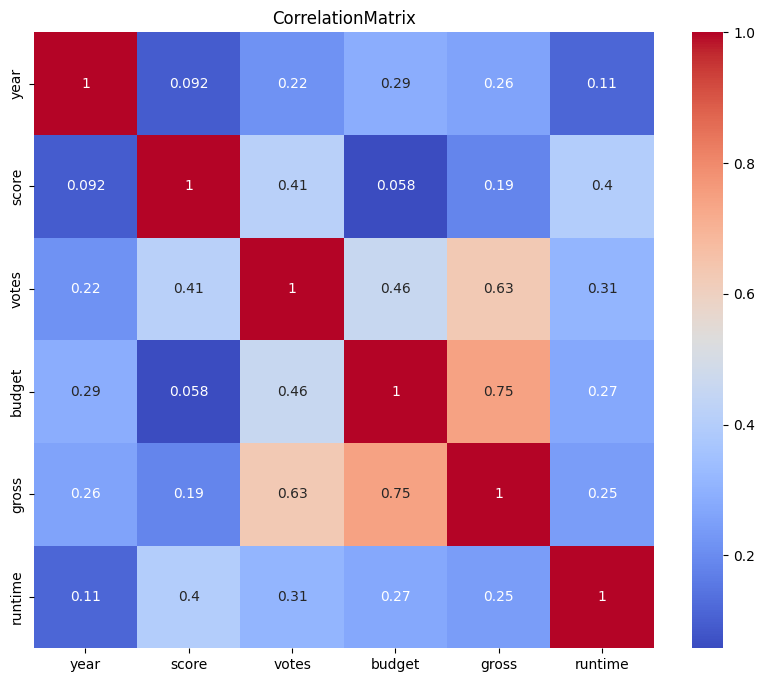

In [36]:
#Run Correlation
numeric_df=df.select_dtypes(include=['int64','float64'])
corr_matrix=numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('CorrelationMatrix')
plt.show()

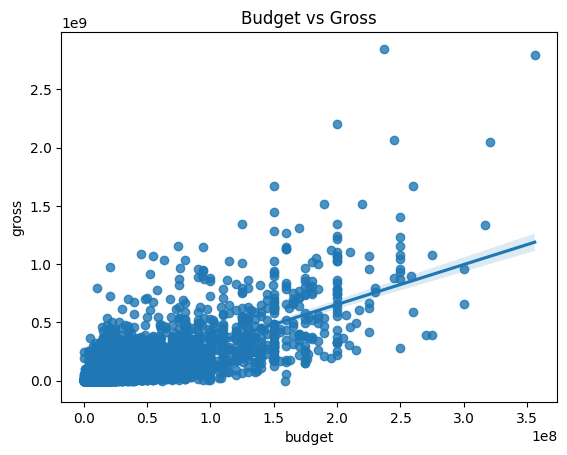

In [37]:
#Budget vs Gross
sns.regplot(x='budget', y='gross', data=df)
plt.title('Budget vs Gross')
plt.show()

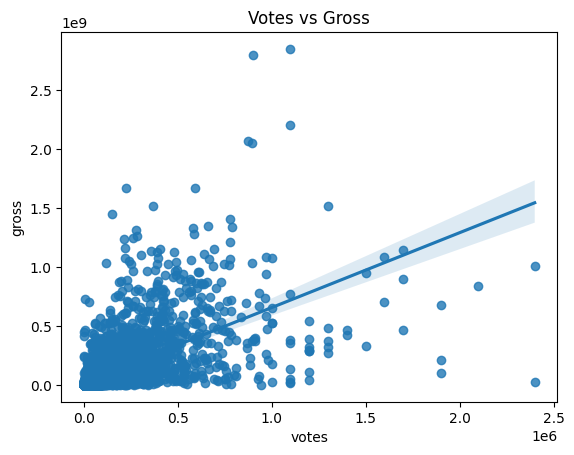

In [38]:
#Votes vs Gross
sns.regplot(x='votes', y='gross', data=df)
plt.title('Votes vs Gross')
plt.show()

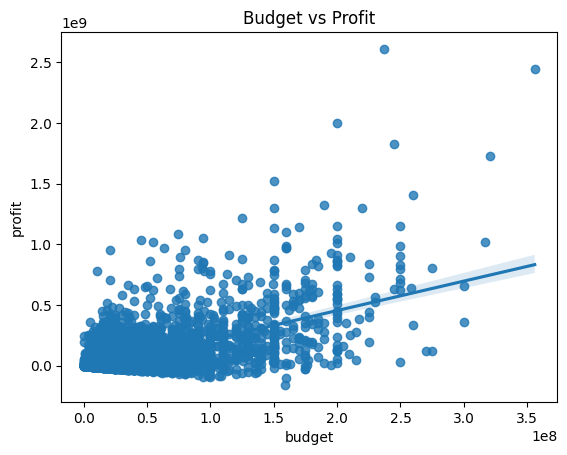

In [42]:
#Profit Analysis
df['profit']=df['gross']-df['budget']
sns.regplot(x='budget', y='profit', data=df)
plt.title('Budget vs Profit')
plt.show()